# 03 - Segmentation

Temporal segmentation of filtered ECG signals into 2-second windows with 0.5-second step size.


In [13]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt

from config import WFDB_RECORDS_DIR
from data_loading import load_record
from segmentation import segment_dataset, segment_record


In [14]:
hea_files = sorted(WFDB_RECORDS_DIR.rglob("*.hea"))
record_path = hea_files[0].with_suffix("")

segments, segment_metadata, fs, leads = segment_record(
    record_path=record_path,
    loader=load_record,
    window_sec=2.0,
    step_sec=0.5,
    lowcut=0.5,
    highcut=40.0,
    order=4,
    apply_filter=True,
)

print("Record:", record_path.name)
print("Segments shape:", segments.shape)
print("Metadata rows:", len(segment_metadata))
segment_metadata.head()


Record: JS00001
Segments shape: (17, 1000, 12)
Metadata rows: 17


,patient_id,segment_id,label_clinico
0,JS00001,JS00001_seg_0000,"164889003,59118001,164934002"
1,JS00001,JS00001_seg_0001,"164889003,59118001,164934002"
2,JS00001,JS00001_seg_0002,"164889003,59118001,164934002"
3,JS00001,JS00001_seg_0003,"164889003,59118001,164934002"
4,JS00001,JS00001_seg_0004,"164889003,59118001,164934002"


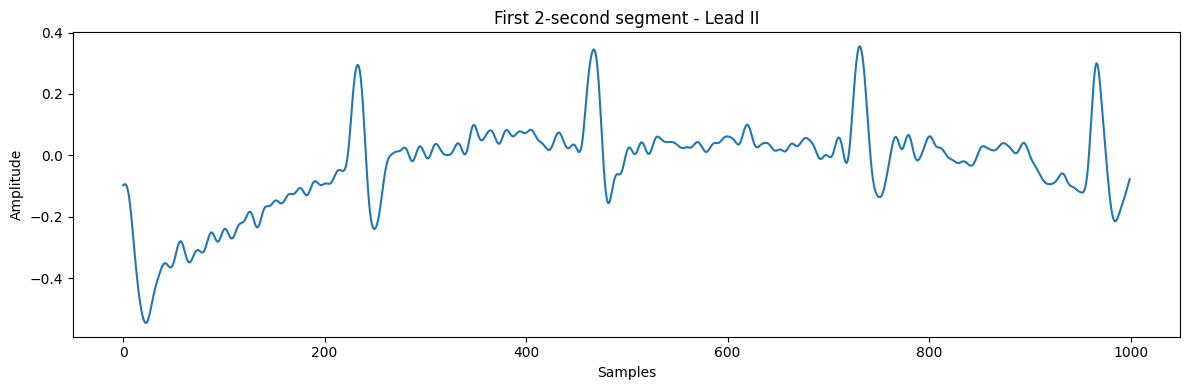

In [15]:
lead_idx = 1

plt.figure(figsize=(12, 4))
plt.plot(segments[0, :, lead_idx])
plt.title(f"First 2-second segment - Lead {leads[lead_idx]}")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()


In [16]:
segments_array, segments_df, errors_df = segment_dataset(
    records=hea_files[:5],
    loader=load_record,
    window_sec=2.0,
    step_sec=0.5,
    lowcut=0.5,
    highcut=40.0,
    order=4,
    apply_filter=True,
)

print("Segments array shape:", segments_array.shape)
print("Segment metadata shape:", segments_df.shape)
print("Errors:", len(errors_df))
segments_df.head()


Segments array shape: (85, 1000, 12)
Segment metadata shape: (85, 3)
Errors: 0


,patient_id,segment_id,label_clinico
0,JS00001,JS00001_seg_0000,"164889003,59118001,164934002"
1,JS00001,JS00001_seg_0001,"164889003,59118001,164934002"
2,JS00001,JS00001_seg_0002,"164889003,59118001,164934002"
3,JS00001,JS00001_seg_0003,"164889003,59118001,164934002"
4,JS00001,JS00001_seg_0004,"164889003,59118001,164934002"
